# **Friends Dataset**

## **Group S**
- Lapo Chiaselotti (308291)
- Silvia Monteleone (315221)
- Riccardo Palleschi (319401)
- Simone Prezioso (324111)

### **Introduction**
Our project studies the social structure of *Friends* (The TV Series) at the episode level. We work from a public character-interaction dataset of **16,569 valid interactions** across **236 episode markers**, from which we build an undirected graph of **747 nodes and 1,610 edges** in which each tie records two characters appearing together within an episode. The analysis that follows stays specific to this dataset because the six main characters (Monica, Chandler, Ross, Joey, Rachel, Phoebe) form the narrative core, while recurring and one-off characters shape the periphery, local closure, and diffusion paths.

The notebook is organized along with the assignments on MyLuiss. Weeks 1-2 establish the basic graph and the giant component, then quantify clustering both per node and as a global average. Week 3 contrasts node clustering against the average clustering of each node's neighbors. Week 5 computes betweenness and PageRank centralities and confirms that the main cast dominates both rankings. Week 6 detects communities through greedy modularity and label propagation, validates the chosen partition, and exports it for Gephi Lite visualization. Week 7 ranks missing-link candidates with Common Neighbors and Adamic-Adar. Week 9 calibrates a preferential attachment model against the real graph, and Week 10 simulates Independent Cascade contagion under varying origin, seed size, and transmission probability.

### **Notebook Structure**
- Data Loading
- Data Exploration
- Weekly Tasks
- Conclusion

## **1. Data Loading**

In [29]:
# Imports, setup, and reproducibility
import random
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 20)
pd.set_option("display.precision", 6)

DATA_PATH = Path("data/friends_episodes.txt")
OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

print("Environment ready.")
print(f"Data path: {DATA_PATH.resolve()}")
print(f"Out dir: {OUT_DIR.resolve()}")


Environment ready.
Data path: C:\Users\simon\Desktop\SNA\data\friends_episodes.txt
Out dir: C:\Users\simon\Desktop\SNA\out


### **1.1 Load Interaction Records**

We parse the interaction log and check the basic integrity of the file before constructing the network.


In [30]:
def load_interactions(path: Path) -> pd.DataFrame:
    """Load valid interaction rows; skip blank and metadata lines."""
    rows = []
    total_nonempty = 0
    metadata_lines = 0
    episode_markers = 0
    skipped_malformed = 0

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            total_nonempty += 1

            if line.startswith("#"):
                metadata_lines += 1
                tokens_after_hash = line[1:].strip().lower().split()
                if tokens_after_hash:
                    marker = tokens_after_hash[0]
                    if marker.startswith("s") and "e" in marker:
                        episode_markers += 1
                continue

            tokens = line.split()
            if len(tokens) != 2:
                skipped_malformed += 1
                continue

            rows.append((tokens[0], tokens[1]))

    df = pd.DataFrame(rows, columns=["source", "target"])
    df.attrs["total_nonempty"] = total_nonempty
    df.attrs["metadata_lines"] = metadata_lines
    df.attrs["episode_markers"] = episode_markers
    df.attrs["valid_rows"] = len(df)
    df.attrs["skipped_malformed"] = skipped_malformed
    return df

interactions_df = load_interactions(DATA_PATH)

loading_summary = pd.Series(
    {
        "nonempty_lines_in_file": interactions_df.attrs["total_nonempty"],
        "metadata_lines": interactions_df.attrs["metadata_lines"],
        "episode_markers": interactions_df.attrs["episode_markers"],
        "valid_interaction_rows": interactions_df.attrs["valid_rows"],
        "skipped_malformed_rows": interactions_df.attrs["skipped_malformed"],
    }
)

display(loading_summary.to_frame("value"))
display(interactions_df.head(10))

assert interactions_df.shape[1] == 2
assert interactions_df.columns.tolist() == ["source", "target"]
assert interactions_df.notna().all().all()


,value
nonempty_lines_in_file,16838
metadata_lines,269
episode_markers,236
valid_interaction_rows,16569
skipped_malformed_rows,0


,source,target
0,Monica,Joey
1,Chandler,Monica
2,Phoebe,Monica
3,Chandler,Monica
4,Chandler,Phoebe
5,Chandler,Joey
6,Ross,Phoebe
7,Ross,Monica
8,Ross,Joey
9,Ross,Chandler


The parsed file contains **16,569 valid interactions** across **236 episode markers**, with no malformed interaction rows. This gives us a clean edge-list foundation. The first rows already show the format clearly: each line records a pair of characters that interacted within an episode context.


## **2. Data Exploration**

Before building the graph, we inspect the two quantities that will drive the network: how often each character appears in interaction rows, and which unordered character pairs repeat most frequently. The pair counts become edge weights in the weighted graph.


In [31]:
character_activity = (
    pd.Series(interactions_df[["source", "target"]].to_numpy().ravel())
    .value_counts()
    .rename_axis("character")
    .reset_index(name="interaction_mentions")
)

pair_frequency = (
    interactions_df.apply(
        lambda row: tuple(sorted((row["source"], row["target"]))), axis=1
    )
    .value_counts()
    .rename_axis("pair")
    .reset_index(name="weight")
)

top_pairs = pair_frequency.head(15).copy()
top_pairs[["source", "target"]] = pd.DataFrame(
    top_pairs["pair"].tolist(), index=top_pairs.index
)
top_pairs = top_pairs[["source", "target", "weight"]]

display(character_activity.head(15))
display(top_pairs)


,character,interaction_mentions
0,Monica,4987
1,Chandler,4983
2,Ross,4769
3,Joey,4630
4,Rachel,4572
5,Phoebe,4392
6,Judy,182
7,Mike,181
8,Jack,180
9,Gunther,109


,source,target,weight
0,Chandler,Monica,1139
1,Chandler,Joey,1040
2,Rachel,Ross,945
3,Monica,Phoebe,915
4,Chandler,Ross,821
5,Monica,Rachel,820
6,Phoebe,Rachel,799
7,Joey,Ross,773
8,Joey,Monica,752
9,Monica,Ross,736


The exploration confirms the expected Friends structure. Monica, Chandler, Ross, Joey, Rachel, and Phoebe dominate interaction volume, while the strongest weighted ties are almost entirely main-cast pairs such as Chandler-Monica, Chandler-Joey, and Rachel-Ross. This suggests a dense narrative core surrounded by many weaker peripheral connections.


## **Week 1**


### **1.1 Graph Building**

We construct two undirected NetworkX graphs from the same interaction table:

- `G_unweighted`: one edge per character pair, used for structural tasks.
- `G_weighted`: one edge per character pair with `weight` equal to repeated interactions.

Following the book's terminology, the Friends network is a graph `G` with `N` nodes and `L` links. A link `(i, j)` joins two characters, and in the weighted version the link also has a weight `w` representing the number of repeated interactions between those two characters.


In [32]:
def build_graph(df: pd.DataFrame, weighted: bool = False) -> nx.Graph:
    """Build an undirected graph from interaction rows."""
    G = nx.Graph()
    if weighted:
        for source, target in df[["source", "target"]].itertuples(
            index=False, name=None
        ):
            u, v = (source, target) if source <= target else (target, source)
            if G.has_edge(u, v):
                G[u][v]["weight"] += 1
            else:
                G.add_edge(u, v, weight=1)
    else:
        G.add_edges_from(
            df[["source", "target"]].itertuples(index=False, name=None)
        )
    return G

G_unweighted = build_graph(interactions_df, weighted=False)
G_weighted = build_graph(interactions_df, weighted=True)

graph_build_summary = pd.Series(
    {
        "nodes": G_unweighted.number_of_nodes(),
        "unweighted_edges": G_unweighted.number_of_edges(),
        "weighted_edges": G_weighted.number_of_edges(),
        "total_edge_weight": sum(
            data["weight"] for _, _, data in G_weighted.edges(data=True)
        ),
        "self_loops": nx.number_of_selfloops(G_unweighted),
        "is_directed": G_unweighted.is_directed(),
    }
)

display(graph_build_summary.to_frame("value"))

assert G_unweighted.number_of_nodes() == G_weighted.number_of_nodes()
assert G_unweighted.number_of_edges() == G_weighted.number_of_edges()
assert graph_build_summary["total_edge_weight"] == len(interactions_df)


,value
nodes,747
unweighted_edges,1610
weighted_edges,1610
total_edge_weight,16569
self_loops,0
is_directed,False


### **Interpretation**

The graph contains **747 characters** and **1,610 unique undirected relationships**. The total weighted edge count equals the number of valid interaction rows, confirming that repeated interactions are preserved in `G_weighted` while structural analyses can still use the simpler unweighted graph.


### **1.2 Basic Network Statistics**

We compute the main size and sparsity indicators using the book's notation: `N` for nodes, `L` for links, `d` for density, and `<k>` for average degree.

$$
L_{max}=\binom{N}{2}=\frac{N(N-1)}{2}
$$

$$
d=\frac{L}{L_{max}}=\frac{2L}{N(N-1)}
$$

$$
\langle k\rangle=\frac{\sum_i k_i}{N}=\frac{2L}{N}
$$


In [33]:
n_nodes = G_unweighted.number_of_nodes()
n_edges = G_unweighted.number_of_edges()
avg_degree = float(np.mean([deg for _, deg in G_unweighted.degree()]))
density = nx.density(G_unweighted)

week1_table = pd.Series(
    {
        "nodes": n_nodes,
        "edges": n_edges,
        "average_degree": avg_degree,
        "density": density,
        "is_directed": G_unweighted.is_directed(),
    }
)
display(week1_table.to_frame("value"))


,value
nodes,747
edges,1610
average_degree,4.310576
density,0.005778
is_directed,False


### **Interpretation**

The network is large but very sparse: **747 nodes**, **1,610 edges**, average degree about **4.31**, and density about **0.0058**. This is consistent with a television cast network where a small set of recurring characters connects many episode-specific characters, instead of every character interacting with everyone else.


### **1.3 Graph Visualization**

The spring layout below highlights the six main characters and uses edge thickness to reflect repeated interactions in the weighted graph.


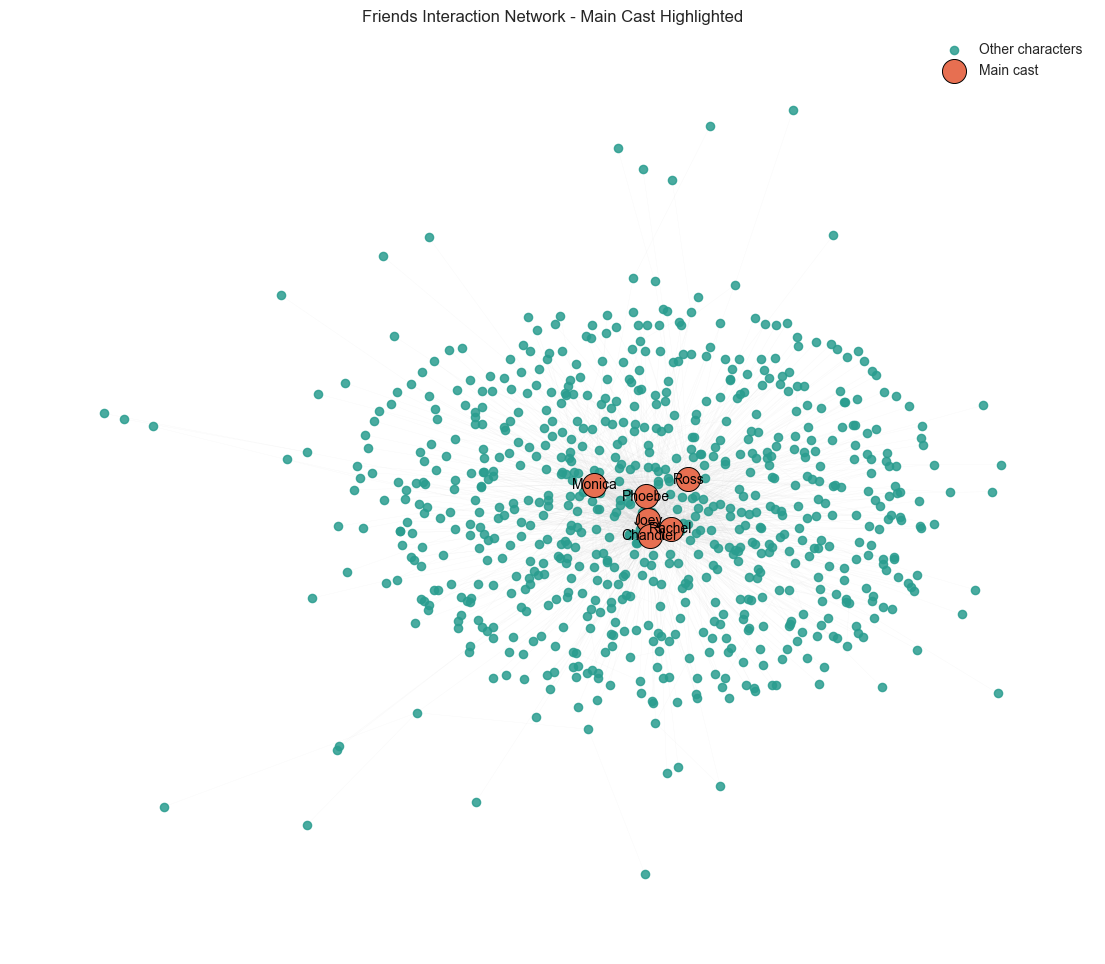

In [34]:
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G_unweighted, seed=RANDOM_SEED, k=0.14)

edge_weights = np.array(
    [data["weight"] for _, _, data in G_weighted.edges(data=True)], dtype=float
)
edge_widths = 0.2 + 2.3 * (edge_weights / edge_weights.max())

nx.draw_networkx_edges(
    G_weighted,
    pos,
    edge_color="lightgray",
    alpha=0.22,
    width=edge_widths,
)

main_cast = ["Monica", "Rachel", "Phoebe", "Joey", "Chandler", "Ross"]
labels = {node: node for node in main_cast if node in G_unweighted.nodes()}
other_nodes = [n for n in G_unweighted.nodes() if n not in labels]

nx.draw_networkx_nodes(
    G_unweighted,
    pos,
    nodelist=other_nodes,
    node_size=35,
    node_color="#2a9d8f",
    alpha=0.85,
    label="Other characters",
)
nx.draw_networkx_nodes(
    G_unweighted,
    pos,
    nodelist=list(labels.keys()),
    node_size=300,
    node_color="#e76f51",
    edgecolors="black",
    linewidths=0.7,
    label="Main cast",
)
nx.draw_networkx_labels(pos=pos, G=G_unweighted, labels=labels, font_size=10)

plt.title("Friends Interaction Network - Main Cast Highlighted")
plt.legend(loc="upper right", scatterpoints=1, fontsize=10, framealpha=0.85)
plt.axis("off")
plt.show()

### **Graph Analysis**

The main cast sits near the visual core and carries many of the thickest ties, with Chandler-Monica, Chandler-Joey, and Rachel-Ross forming the densest sub-region. Peripheral characters appear around that center with thinner, more localized links, often clustered into small story-driven satellites. The figure therefore supports the numerical baseline: with **average degree 4.31** and **density 0.006**, the Friends network is sparse overall yet organized around a very strong central ensemble whose ties dwarf typical pairwise frequencies elsewhere in the graph.

## **Week 2**


### **2.1 Largest Connected Component**

For clustering analysis, we work on the largest connected component so all nodes are part of the same reachable structure. In the book's terminology, a disconnected network is composed of connected components, and the largest one is the giant component.


In [35]:
def largest_component_graph(G: nx.Graph) -> nx.Graph:
    """Return largest connected component as a copy."""
    if G.number_of_nodes() == 0:
        return G.copy()
    lcc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(lcc_nodes).copy()

G_week2 = largest_component_graph(nx.Graph(G_unweighted))

### **Interpretation**

Restricting to the largest component avoids isolated-fragment artifacts and keeps the denominator of all clustering calculations meaningful. In this dataset, the giant component absorbs essentially the entire main-cast core and the large majority of recurring social structure into one common graph domain, so almost no analytically interesting nodes are dropped. The few characters left outside it appear in episode-isolated scenes that would not contribute to triangle counts, neighbor-clustering, or diffusion paths anyway.

### **2.2 Local Clustering**

We compute local clustering manually and compare it against NetworkX for each node. The book defines the clustering coefficient of node `i` as the fraction of pairs of `i`'s neighbors that are connected to each other:

$$
C(i)=\frac{\tau(i)}{\tau_{max}(i)}=\frac{\tau(i)}{\binom{k_i}{2}}=\frac{2\tau(i)}{k_i(k_i-1)}
$$


In [36]:
def clustering_per_node_manual(G: nx.Graph) -> dict[str, float]:
    """Manual local clustering coefficient for each node."""
    output = {}
    for node in G.nodes():
        neigh = list(G.neighbors(node))
        k = len(neigh)
        if k < 2:
            output[node] = 0.0
            continue

        closed_triplets = 0
        for i, u in enumerate(neigh):
            for v in neigh[i + 1 :]:
                if G.has_edge(u, v):
                    closed_triplets += 1

        output[node] = (2.0 * closed_triplets) / (k * (k - 1))
    return output

manual_local = clustering_per_node_manual(G_week2)
nx_local = nx.clustering(G_week2)

comparison = pd.DataFrame(
    {
        "manual": pd.Series(manual_local),
        "networkx": pd.Series(nx_local),
    }
)
comparison["abs_diff"] = (comparison["manual"] - comparison["networkx"]).abs()

display(comparison.sort_values("abs_diff", ascending=False).head(10))

,manual,networkx,abs_diff
Monica,0.024061,0.024061,0.0
Joey,0.014506,0.014506,0.0
Chandler,0.019309,0.019309,0.0
Phoebe,0.024296,0.024296,0.0
Ross,0.017855,0.017855,0.0
Rachel,0.020519,0.020519,0.0
waitress,1.000000,1.000000,0.0
LeonardGreen,0.611111,0.611111,0.0
Paul,1.000000,1.000000,0.0
Barry,0.333333,0.333333,0.0


### **Interpretation**

The manual implementation matches NetworkX exactly up to numerical precision. This matters because the later distributional analysis depends on the clustering values, not just the average. The top rows shown are not errors; they simply confirm that even highly visible nodes have zero absolute difference between implementations.


### **2.3 Average Clustering and Transitivity**

We aggregate local closure and compare it with global triadic closure. The book defines the clustering coefficient of the entire network as the average of node clustering coefficients over nodes with degree greater than one:

$$
C=\frac{\sum_{i:k_i>1} C(i)}{N_{k>1}}
$$

Transitivity is still reported as a NetworkX comparison metric, but no separate displayed formula is used here because the book section we follow introduces clustering through `C(i)` and `C`.


In [37]:
def average_clustering_manual(G: nx.Graph) -> float:
    coeffs = clustering_per_node_manual(G)
    return float(np.mean(list(coeffs.values())))

manual_avg = average_clustering_manual(G_week2)
nx_avg = nx.average_clustering(G_week2)
nx_transitivity = nx.transitivity(G_week2)

stats_week2 = pd.Series(
    {
        "manual_average_clustering": manual_avg,
        "networkx_average_clustering": nx_avg,
        "networkx_transitivity": nx_transitivity,
        "max_abs_node_diff": comparison["abs_diff"].max(),
    }
)
display(stats_week2.to_frame("value"))

assert comparison["abs_diff"].max() < 1e-12
assert abs(manual_avg - nx_avg) < 1e-12

,value
manual_average_clustering,0.500264
networkx_average_clustering,0.500264
networkx_transitivity,0.033501
max_abs_node_diff,0.000000


### **Interpretation**

Average clustering is about **0.50**, while transitivity is only about **0.034**. This contrast is important: many small peripheral neighborhoods are fully or nearly closed, but the global graph is dominated by high-degree central characters whose many possible triangles are not all closed. Local closure is therefore high, while global closure remains low.


## **Week 3**


### **3.1 Average Neighbor Clustering**

For each node, we compute the average clustering coefficient of its neighbors. This is an assignment-specific comparison derived from the clustering values above, so we describe it in prose rather than introducing an extra formula not shown in the book.


In [38]:
def neighbor_avg_clustering(
    G: nx.Graph, clustering_dict: dict[str, float]
) -> dict[str, float]:
    out = {}
    for node in G.nodes():
        neigh = list(G.neighbors(node))
        if not neigh:
            out[node] = 0.0
        else:
            out[node] = float(np.mean([clustering_dict[n] for n in neigh]))
    return out

neighbor_average = neighbor_avg_clustering(G_week2, manual_local)

### **Interpretation**

This metric shifts the question from a node's own closed triangles to the social environment around it. A character can have low personal clustering while still being connected to tightly clustered neighbors, which is common in core-periphery story networks: the main cast itself is loosely closed because they bridge many disjoint guest groups, but those guest groups internally form tight cliques. The neighbor-average view picks this up and complements the node-level coefficient, which on its own risks understating embeddedness for high-degree bridging characters.

### **3.2 CDF Comparison**

We compare the cumulative distributions of node clustering and average neighbor clustering. The book introduces cumulative distributions as a way to compare how broadly a network quantity varies across nodes, so we keep the focus on the plotted distributions rather than adding a separate empirical-CDF formula.


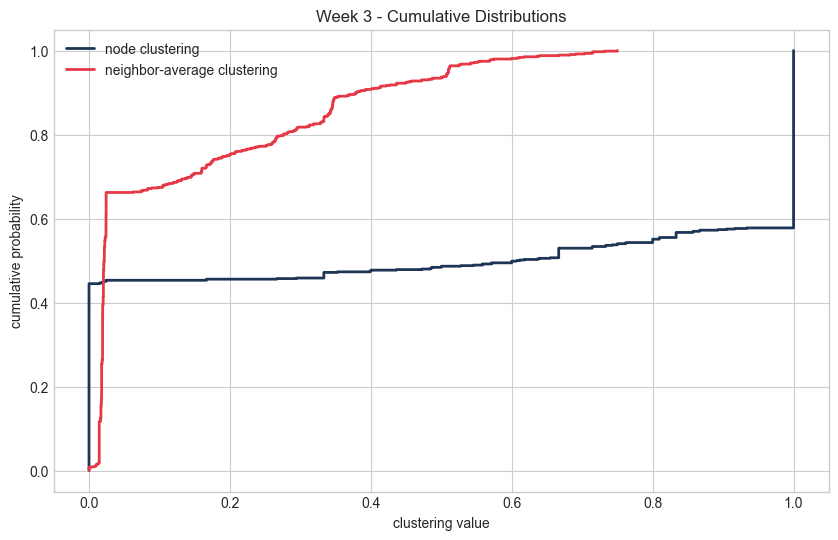

In [39]:
def empirical_cdf(values) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(list(values), dtype=float)
    if arr.size == 0:
        return np.array([]), np.array([])
    x = np.sort(arr)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x1, y1 = empirical_cdf(manual_local.values())
x2, y2 = empirical_cdf(neighbor_average.values())

plt.figure(figsize=(10, 6))
plt.step(x1, y1, where="post", linewidth=2, color="#1d3557", label="node clustering")
plt.step(
    x2,
    y2,
    where="post",
    linewidth=2,
    color="#e63946",
    label="neighbor-average clustering",
)
plt.xlabel("clustering value")
plt.ylabel("cumulative probability")
plt.title("Week 3 - Cumulative Distributions")
plt.legend()
plt.show()

### **Graph Analysis**

The two CDFs describe different structural views. Node clustering has many extreme values because small supporting-character neighborhoods can be perfectly closed. Neighbor-average clustering is smoother and lower for many nodes, showing that proximity to the main cast often means being attached to broad, less closed neighborhoods.


### **3.3 Quantile Summary**

We summarize both distributions at quartile levels. The quartile table is a compact numerical companion to the cumulative-distribution plot, so no additional displayed formula is needed.


In [40]:
quantiles = pd.DataFrame(
    {
        "node_clustering": pd.Series(manual_local).quantile([0.25, 0.5, 0.75]),
        "neighbor_avg_clustering": pd.Series(neighbor_average).quantile(
            [0.25, 0.5, 0.75]
        ),
    }
)
quantiles.index = ["Q1", "Median", "Q3"]
display(quantiles)

,node_clustering,neighbor_avg_clustering
Q1,0.000000,0.017855
Median,0.607143,0.021380
Q3,1.000000,0.195799


### **Interpretation**

The median node clustering is about **0.607**, while the median neighbor-average clustering is only about **0.021**. This gap shows that many characters belong to tiny closed local groups (often guest-cast triangles around a single main character), but their neighbors are typically connected to much broader and less closed parts of the network. The Q3 of the neighbor-average distribution at **0.196** confirms that even the more embedded fraction of nodes still sits in environments far less closed than their own immediate triangle.

## **Week 5**


### **Choice of Centrality Measures**

We use two complementary notions of importance:

- **Betweenness centrality**, which rewards characters that sit on shortest paths and connect otherwise distant parts of the graph.
- **PageRank**, which rewards characters connected to other important characters.

### **5.1 Compute Betweenness and PageRank**

We used the books definition, it defines betweenness of node `i` by counting the fraction of shortest paths between other nodes that pass through `i`:

$$
b_i=\sum_{h\ne j\ne i}\frac{\sigma_{hj}(i)}{\sigma_{hj}}
$$

For PageRank, the book uses teleportation factor `alpha` and damping factor `1 - alpha`:

$$
R_t(i)=\frac{\alpha}{N}+(1-\alpha)\sum_{j\in pred(i)}\frac{R_{t-1}(j)}{k^{out}(j)}
$$

Note: in `nx.pagerank`, the parameter `alpha` is the *damping* factor (= `1 - α_book`), so the call `nx.pagerank(G, alpha=0.85)` corresponds to teleportation 0.15 in the formula above.


In [41]:
betweenness = nx.betweenness_centrality(G_week2, normalized=True)
pagerank = nx.pagerank(G_week2, alpha=0.85)

### **Interpretation**

The two measures capture different but related roles. Betweenness emphasizes bridging across episode groups and guest-character clusters, while PageRank emphasizes repeated connection to already central characters. Comparing them prevents the analysis from relying on a single definition of importance.


### **5.2 Most Central Characters**

We rank the top nodes under each score and measure how much the two top lists overlap. This overlap is an interpretation aid for the assignment, so it is described in prose rather than with an additional formula.


In [42]:
top_k = 10
top_bet = pd.Series(betweenness, name="betweenness").sort_values(ascending=False).head(top_k)
top_pr = pd.Series(pagerank, name="pagerank").sort_values(ascending=False).head(top_k)

side_by_side = pd.DataFrame(
    {
        "betweenness_node": top_bet.index,
        "betweenness": top_bet.values.round(4),
        "pagerank_node": top_pr.index,
        "pagerank": top_pr.values.round(4),
    },
    index=pd.RangeIndex(start=1, stop=top_k + 1, name="rank"),
)
display(side_by_side)

overlap = sorted(set(top_bet.index) & set(top_pr.index))
print(f"Top-{top_k} overlap size: {len(overlap)}")
print("Overlap nodes:", overlap)

,betweenness_node,betweenness,pagerank_node,pagerank
rank,,,,
1,Joey,0.3238,Joey,0.0806
2,Ross,0.2718,Ross,0.0705
3,Rachel,0.2382,Chandler,0.0668
4,Chandler,0.2312,Rachel,0.0642
5,Phoebe,0.1907,Phoebe,0.0572
6,Monica,0.1832,Monica,0.0567
7,Mike,0.0083,Judy,0.0046
8,Richard,0.0064,Gunther,0.0045
9,Joshua,0.0059,Mike,0.0045


Top-10 overlap size: 7
Overlap nodes: ['Chandler', 'Joey', 'Mike', 'Monica', 'Phoebe', 'Rachel', 'Ross']


### **Interpretation**

The six main characters dominate both measures, with Joey, Ross, Rachel, Chandler, Phoebe, and Monica all appearing near the top. The top-10 overlap has **7 shared nodes**, indicating that brokerage and recursive importance largely agree in this network. Smaller differences, such as guest characters appearing in one list but not the other, add role-specific nuance.


### **5.3 Centrality Distribution**

The cumulative-distribution plot shows whether importance is broadly distributed or concentrated in a small tail. This follows the book's use of cumulative distributions for centrality values without adding a separate empirical-CDF expression.


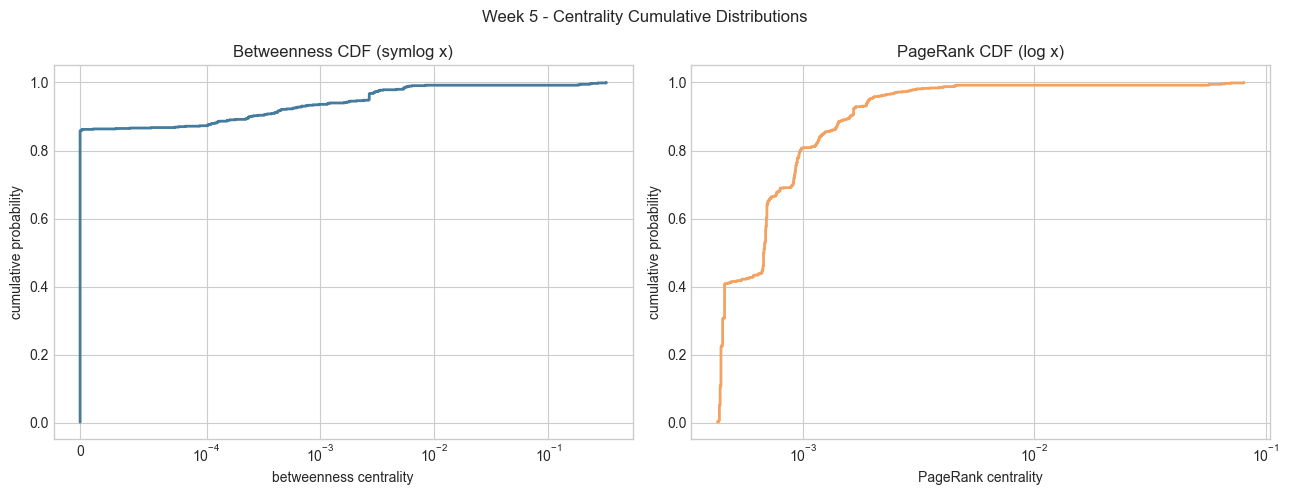

In [43]:
xb, yb = empirical_cdf(betweenness.values())
xp, yp = empirical_cdf(pagerank.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].step(xb, yb, where="post", linewidth=2, color="#457b9d")
axes[0].set_xscale("symlog", linthresh=1e-4)
axes[0].set_xlabel("betweenness centrality")
axes[0].set_ylabel("cumulative probability")
axes[0].set_title("Betweenness CDF (symlog x)")

axes[1].step(xp, yp, where="post", linewidth=2, color="#f4a261")
axes[1].set_xscale("log")
axes[1].set_xlabel("PageRank centrality")
axes[1].set_ylabel("cumulative probability")
axes[1].set_title("PageRank CDF (log x)")

fig.suptitle("Week 5 - Centrality Cumulative Distributions")
plt.tight_layout()
plt.show()


### **Graph Analysis**

Both distributions are strongly right-skewed. Most characters have very small centrality values, clustered tightly near the lower bound on both axes, while the main cast forms a small high-centrality tail clearly separated from the rest. The symlog x-axis on the betweenness panel shows the gap is wide enough to span several orders of magnitude. This concentration explains why origin choice matters later in the contagion experiments: a cascade that starts in the high-tail nodes reaches many parts of the network in one step, while peripheral starts are structurally bottle-necked.

## **Week 6**


### **6.1 Graph Preprocessing and Method Comparison**

The task requires an undirected, unweighted, loop-free graph restricted to the largest connected component. We compare greedy modularity optimization with asynchronous label propagation.

The book defines modularity for an undirected, unweighted network as a partition-quality measure relative to a degree-preserving random baseline:

$$
Q=\frac{1}{L}\sum_C\left(L_C-\frac{k_C^2}{4L}\right)
$$


In [44]:
def community_partitions(G: nx.Graph) -> dict[str, dict[str, int] | float]:
    H = nx.Graph(G)
    H.remove_edges_from(nx.selfloop_edges(H))
    H = largest_component_graph(H)

    greedy_sets = list(nx.algorithms.community.greedy_modularity_communities(H))
    lpa_sets = list(
        nx.algorithms.community.asyn_lpa_communities(H, seed=RANDOM_SEED)
    )

    def to_partition(communities):
        partition = {}
        for cid, community in enumerate(communities):
            for node in community:
                partition[node] = cid
        return partition

    greedy_partition = to_partition(greedy_sets)
    lpa_partition = to_partition(lpa_sets)

    greedy_modularity = nx.algorithms.community.modularity(H, greedy_sets)
    lpa_modularity = nx.algorithms.community.modularity(H, lpa_sets)

    return {
        "greedy_partition": greedy_partition,
        "lpa_partition": lpa_partition,
        "greedy_modularity": float(greedy_modularity),
        "lpa_modularity": float(lpa_modularity),
    }

G_week6 = nx.Graph(G_unweighted)
G_week6.remove_edges_from(nx.selfloop_edges(G_week6))
G_week6 = largest_component_graph(G_week6)

week6 = community_partitions(G_week6)
modularity_df = pd.DataFrame(
    {
        "method": ["greedy_modularity", "label_propagation"],
        "modularity": [week6["greedy_modularity"], week6["lpa_modularity"]],
    }
).sort_values("modularity", ascending=False)
display(modularity_df)

,method,modularity
0,greedy_modularity,0.403801
1,label_propagation,0.367724


### **Interpretation**

Greedy modularity performs best on this graph, with modularity about **0.404** compared with about **0.370** for label propagation. The gap is modest, but the two methods fail in different ways and the comparison is informative:

- **Greedy modularity** is deterministic and converges to a local optimum of Q, but is known to suffer from a **resolution limit**: it can merge small but well-separated communities into a single larger one whenever doing so still yields a higher Q. On Friends this most likely affects the smaller satellite groups around the cast core, which may end up absorbed into a neighboring community rather than standing alone.
- **Asynchronous label propagation** has no objective function and is **stochastic**: a different random seed can produce a meaningfully different partition, and on a graph with a dense core like ours it tends to assign too many nodes to one giant label early in the run.

We pick greedy modularity because it gives the higher Q, is reproducible across runs, and produces a partition that is stable enough to export to Gephi and reuse in later analyses.

### **6.2 Best Partition Validation**

We select the partition with the highest modularity score and verify that every node receives exactly one community label. The selection rule is described in prose because the book presents modularity itself, not an additional best-partition formula.


In [45]:
best_method = modularity_df.iloc[0]["method"]
best_partition = (
    week6["greedy_partition"]
    if best_method == "greedy_modularity"
    else week6["lpa_partition"]
)

print(f"Best method: {best_method}")
print(f"Detected communities: {len(set(best_partition.values()))}")

assert set(best_partition.keys()) == set(G_week6.nodes())
assert modularity_df["modularity"].between(-0.5, 1.0).all()

Best method: greedy_modularity
Detected communities: 11


### **Interpretation**

The selected partition assigns every node in the component and detects **11 communities**. For Friends, this level of granularity is reasonable: the main-cast core connects many smaller episode, family, workplace, and romantic-subplot groups. The greedy modularity score of about **0.404** also exceeds the **0.370** of label propagation, giving a partition that both maximizes intra-community density and remains stable across runs (greedy modularity is deterministic, while LPA is not). This stability is what makes the partition usable downstream as the labeling we export to Gephi.

### **6.3 Community Visualization**

Node color encodes the selected community label in the best partition, and node size encodes degree. We use a `tab20` qualitative palette so the 11 detected communities remain visually separable, and a spring layout with a fixed seed so that structural proximity translates into visual proximity.

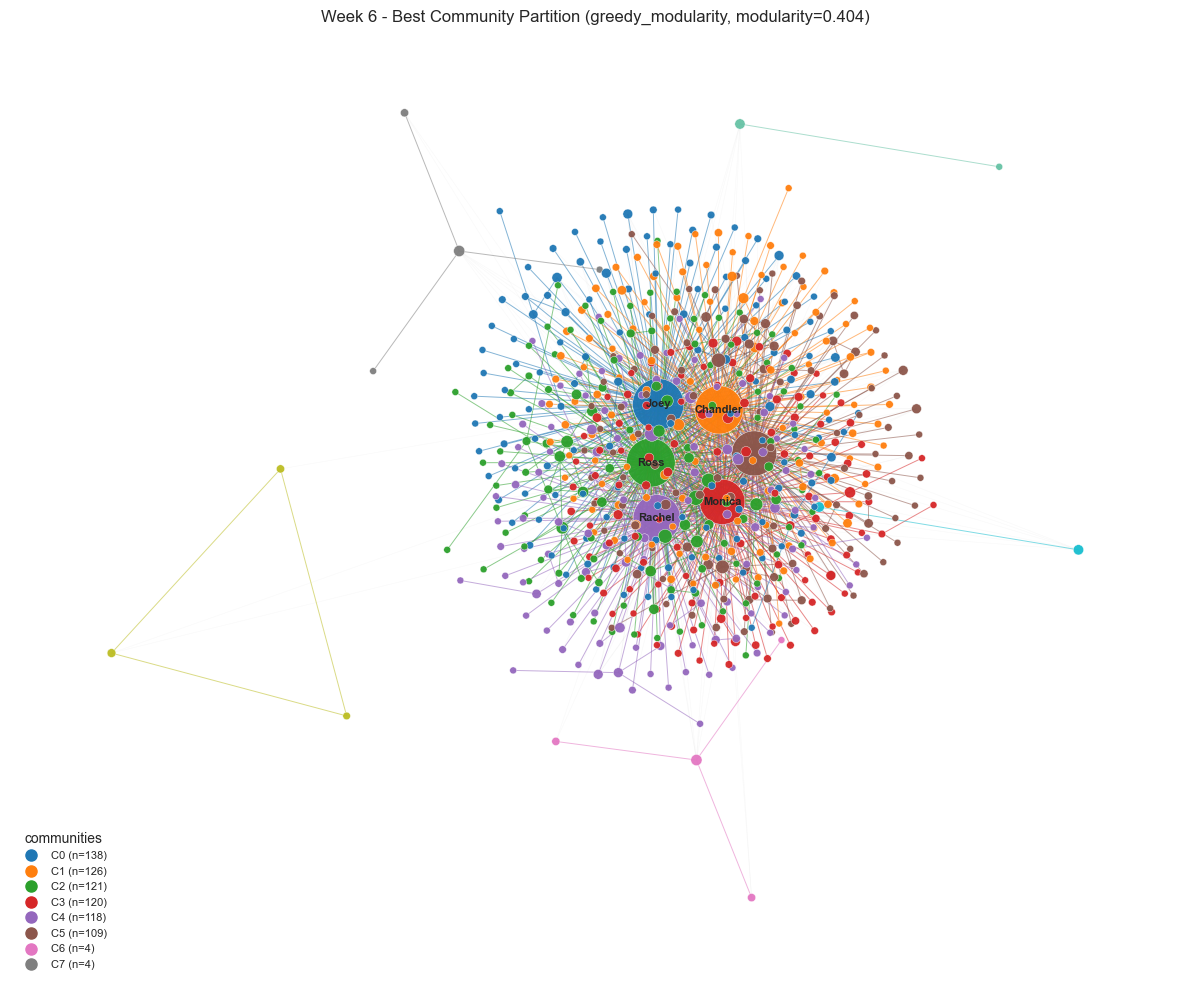

In [46]:
plt.figure(figsize=(12, 10))

communities = {}
for node, cid in best_partition.items():
    communities.setdefault(cid, []).append(node)
ordered_cids = sorted(communities, key=lambda c: -len(communities[c]))

meta = nx.Graph()
meta.add_nodes_from(ordered_cids)
for u, v in G_week6.edges():
    cu, cv = best_partition[u], best_partition[v]
    if cu != cv:
        if meta.has_edge(cu, cv):
            meta[cu][cv]["weight"] += 1
        else:
            meta.add_edge(cu, cv, weight=1)
centroid_pos = nx.spring_layout(meta, seed=RANDOM_SEED, k=1.2, weight="weight")

pos6 = {}
for cid in ordered_cids:
    sub = G_week6.subgraph(communities[cid])
    sub_pos = nx.spring_layout(sub, seed=RANDOM_SEED, k=0.5)
    cx, cy = centroid_pos[cid]
    scale = 0.25 + 0.05 * np.log1p(len(communities[cid]))
    for n, (x, y) in sub_pos.items():
        pos6[n] = (cx + scale * x, cy + scale * y)

palette = [plt.cm.tab10(i) for i in range(10)] + [plt.cm.Set2(i) for i in range(8)]
color_of_cid = {cid: palette[i % len(palette)] for i, cid in enumerate(ordered_cids)}
node_colors = [color_of_cid[best_partition[n]] for n in G_week6.nodes()]
node_sizes = [20 + 5 * G_week6.degree(n) for n in G_week6.nodes()]

intra = [(u, v) for u, v in G_week6.edges() if best_partition[u] == best_partition[v]]
inter = [(u, v) for u, v in G_week6.edges() if best_partition[u] != best_partition[v]]
intra_colors = [color_of_cid[best_partition[u]] for u, _ in intra]

nx.draw_networkx_edges(
    G_week6, pos6, edgelist=inter, edge_color="lightgray", alpha=0.15, width=0.4
)
nx.draw_networkx_edges(
    G_week6, pos6, edgelist=intra, edge_color=intra_colors, alpha=0.55, width=0.7
)
nx.draw_networkx_nodes(
    G_week6,
    pos6,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.95,
    linewidths=0.3,
    edgecolors="white",
)

for cid in ordered_cids[:5]:
    members = communities[cid]
    hub = max(members, key=lambda n: G_week6.degree(n))
    plt.text(
        pos6[hub][0],
        pos6[hub][1],
        str(hub),
        fontsize=8,
        ha="center",
        va="center",
        weight="bold",
    )

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color=color_of_cid[cid],
        label=f"C{cid} (n={len(communities[cid])})",
        markersize=8,
    )
    for cid in ordered_cids[:8]
]
modularity_value = (
    week6["greedy_modularity"]
    if best_method == "greedy_modularity"
    else week6["lpa_modularity"]
)
plt.legend(
    handles=handles, loc="lower left", fontsize=8, framealpha=0.85, title="communities"
)
plt.title(
    f"Week 6 - Best Community Partition ({best_method}, modularity={modularity_value:.3f})"
)
plt.axis("off")
plt.tight_layout()
plt.show()

### **Graph Analysis**

The visualization shows a mixed central region surrounded by smaller colored groups. This is expected for Friends: the main characters bridge many settings, so communities are visible around the periphery but overlap strongly near the core. Several of the smaller satellite groups correspond to family clusters, workplaces (Central Perk staff, Ross's museum, Rachel's fashion office), and short romantic arcs. The spatial separation between these satellites and the core mirrors the modularity gain: most intra-community density comes from peripheral cliques rather than from inside the cast itself.

### **6.4 Export for Gephi Lite**

The selected partition is exported as node and edge tables plus a GEXF file. These files can be opened in Gephi Lite for external inspection and styling.


In [47]:
export_dir = OUT_DIR / "week6_gephi"
export_dir.mkdir(parents=True, exist_ok=True)

nodes_path = export_dir / "nodes.csv"
edges_path = export_dir / "edges.csv"
gexf_path = export_dir / "best_partition_graph.gexf"

nodes_df = pd.DataFrame(
    {"Id": list(best_partition.keys()), "community": list(best_partition.values())}
)
edges_df = nx.to_pandas_edgelist(G_week6).rename(
    columns={"source": "Source", "target": "Target"}
)

nodes_df.to_csv(nodes_path, index=False)
edges_df.to_csv(edges_path, index=False)

G_export = G_week6.copy()
nx.set_node_attributes(G_export, best_partition, name="community")
nx.write_gexf(G_export, gexf_path)

print("Gephi export files:")
print(nodes_path)
print(edges_path)
print(gexf_path)

Gephi export files:
out\week6_gephi\nodes.csv
out\week6_gephi\edges.csv
out\week6_gephi\best_partition_graph.gexf


### **Gephi Lite Visualization**

The graph below was rendered in Gephi Lite from the GEXF file exported above. Node size encodes degree; orange peripheral nodes are one-off characters, while the blue/green central hubs are the recurring main cast (Joey, Chandler, Rachel, Ross, Phoebe).

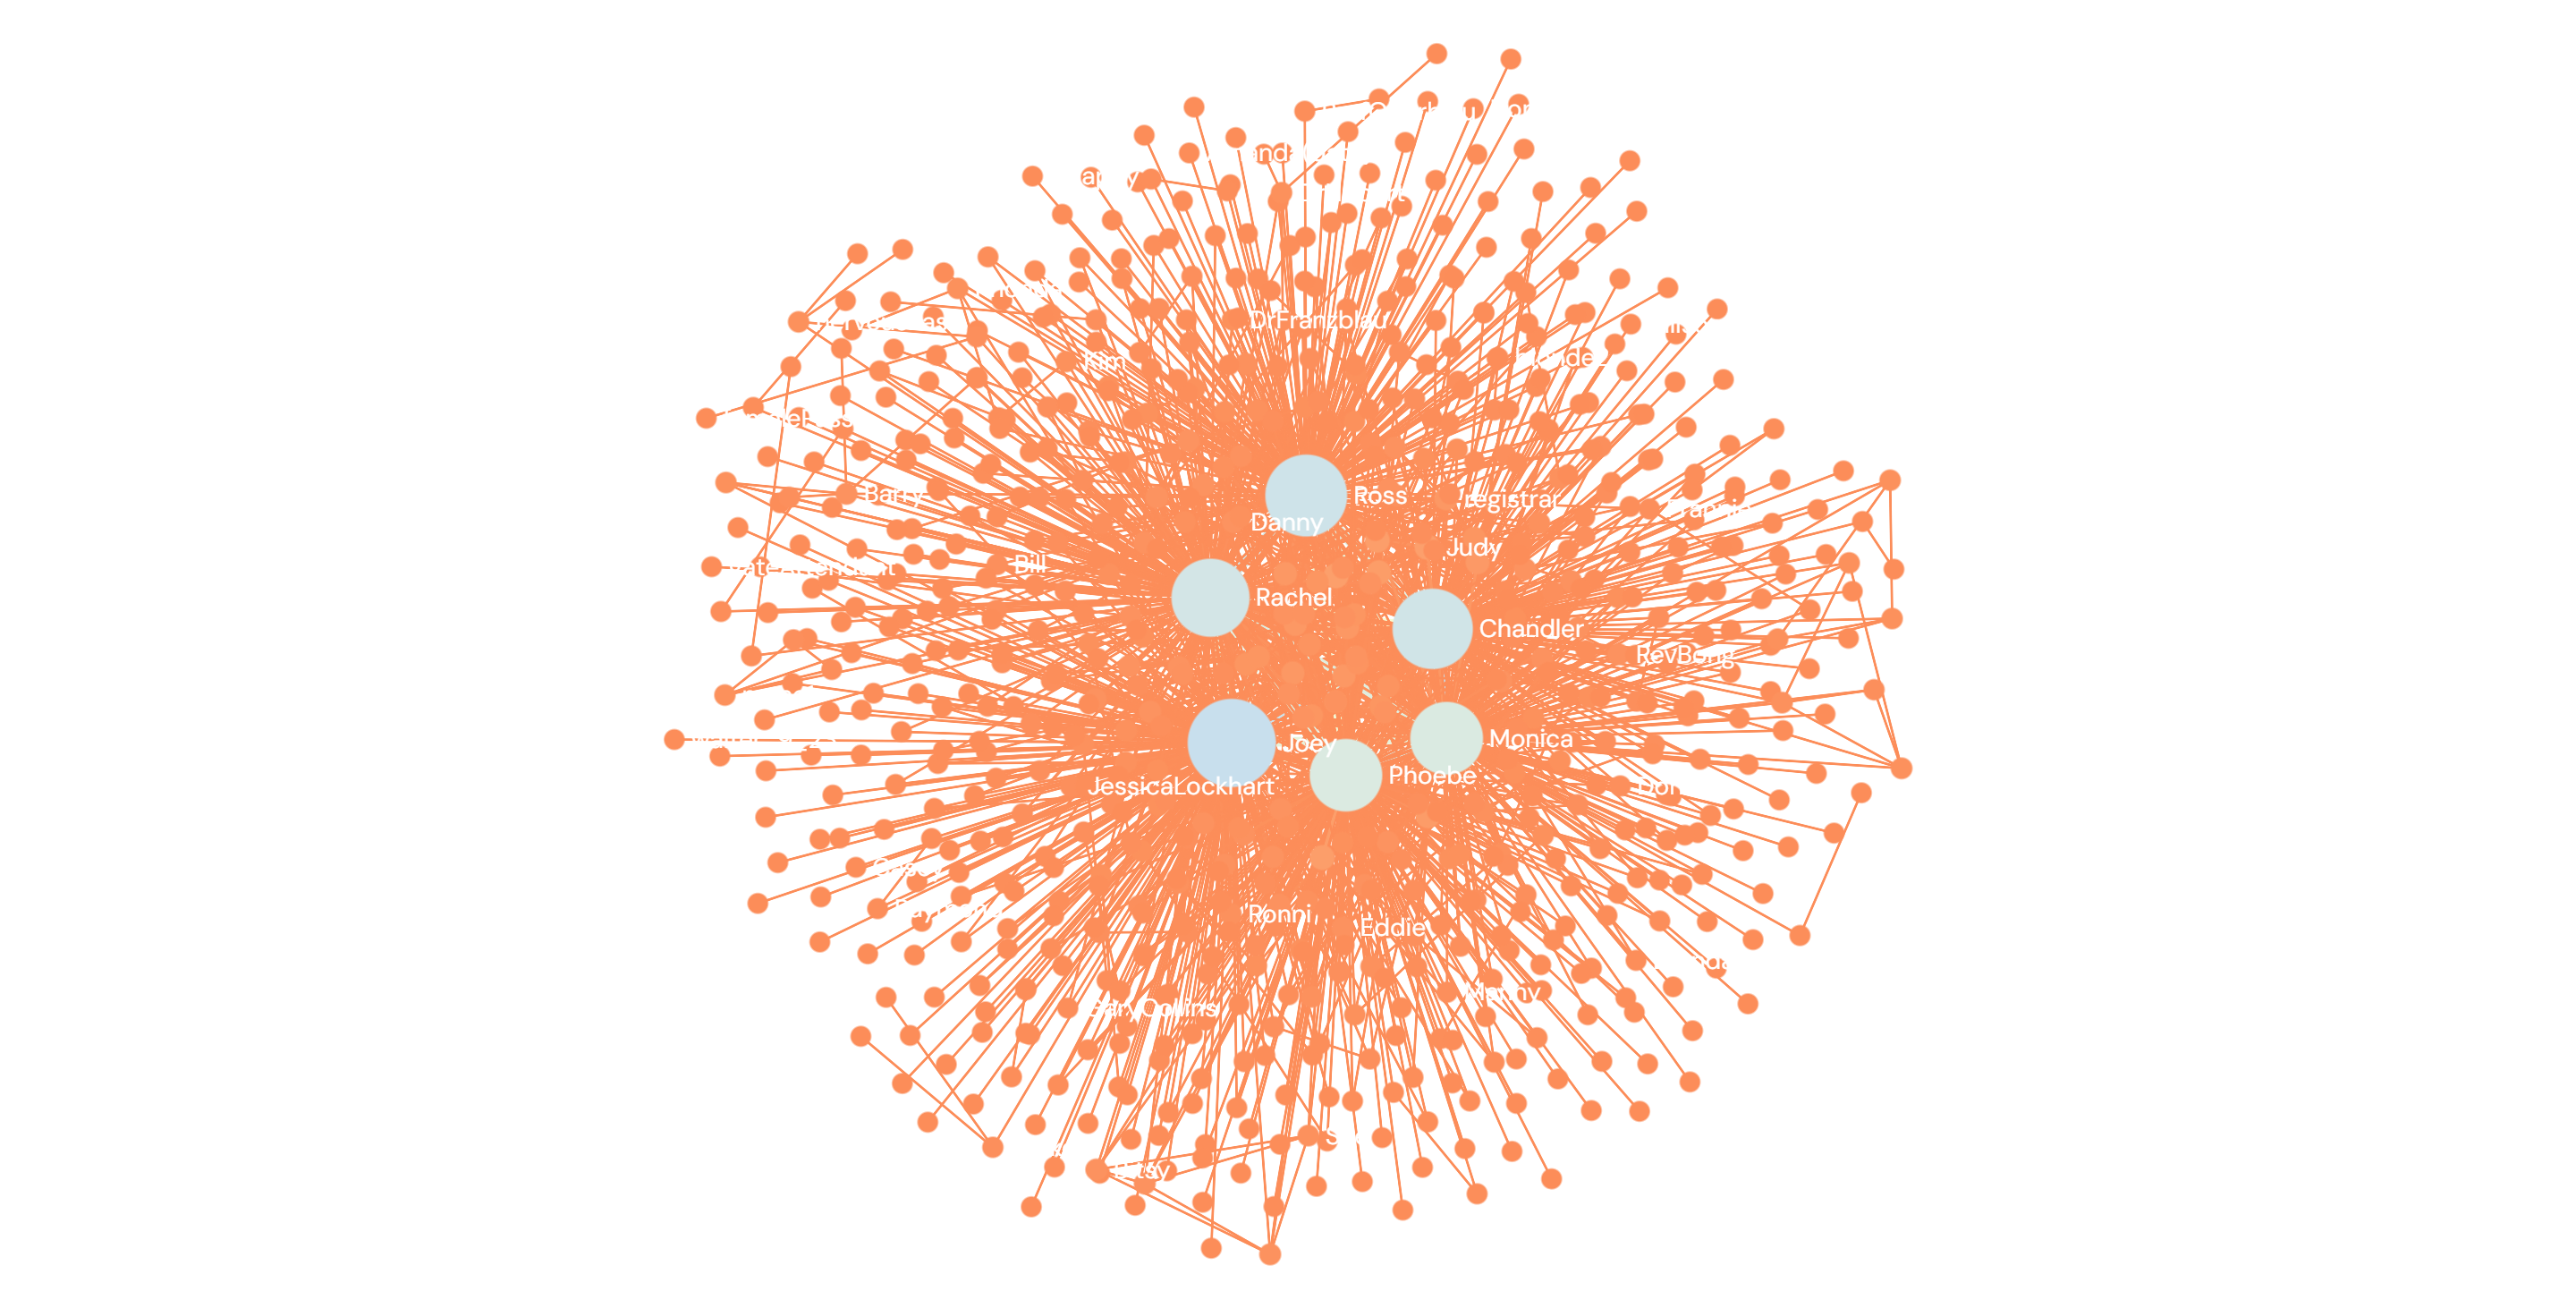

### **Interpretation**

The export preserves both topology and community labels, making the Week 6 result reproducible outside the notebook. The relevant files are written under `out/week6_gephi/`.


## **Week 7**


### **7.1 Graph Preprocessing**

We again use an undirected, unweighted, loop-free largest connected component. Candidate links are all missing edges in that graph, restricted to pairs of nodes that already belong to the giant component. This is the natural domain for shared-neighbor link prediction: scores like Common Neighbors and Adamic-Adar are zero by construction for any pair sitting in different components, so including those pairs would only add noise to the ranking.

In [48]:
def compute_link_scores(G: nx.Graph) -> pd.DataFrame:
    """Compute CN, AA, scaled versions, and a combined score for every missing link."""
    H = nx.Graph(G)
    H.remove_edges_from(nx.selfloop_edges(H))

    missing = list(nx.non_edges(H))
    neighbors = {node: set(H.neighbors(node)) for node in H.nodes()}

    cn_values = [len(neighbors[u] & neighbors[v]) for u, v in missing]
    aa_scores = {(u, v): score for u, v, score in nx.adamic_adar_index(H, missing)}

    df = pd.DataFrame(missing, columns=["node_u", "node_v"])
    df["CN"] = cn_values
    df["AA"] = [aa_scores[(u, v)] for u, v in missing]

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[["CN", "AA"]])
    df["CN_scaled"] = scaled[:, 0]
    df["AA_scaled"] = scaled[:, 1]
    df["sum_score"] = df["CN_scaled"] + df["AA_scaled"]
    df["mean_score"] = df["sum_score"] / 2

    return df

G_week7 = largest_component_graph(G_unweighted)

scores = compute_link_scores(G_week7)

### **Interpretation**

This preprocessing keeps link prediction focused on plausible structural gaps inside the main connected network, rather than pairs involving disconnected fragments or self-loops. It also fixes the candidate set so that the same denominator applies to both CN and AA, which keeps the min-max scaled scores and the combined index comparable across pairs and across the two methods.

### **7.2 Choice of Indices and Top Missing Links**

We use two local topological indices:

- **Common Neighbors (CN)** counts shared neighbors.
- **Adamic-Adar (AA)** downweights very popular common neighbors.

CN and AA are first min-max rescaled to `[0, 1]` so the two columns sit on the same scale. Two combined scores are then exposed:

- `sum_score = CN_scaled + AA_scaled` — literally the sum of the two scaled indices, as the assignment step requests.
- `mean_score = sum_score / 2` — the arithmetic mean of the rescaled values, as the assignment note clarifies.

Because the mean is just the sum divided by two, the two scores produce identical rankings; we keep both columns so each reading of the spec is honored explicitly. The top-10 ranking below uses `sum_score`.

In [49]:
assert not scores.empty
assert scores[["CN_scaled", "AA_scaled"]].min().min() >= -1e-12
assert scores[["CN_scaled", "AA_scaled"]].max().max() <= 1 + 1e-12
assert (scores["mean_score"] - scores["sum_score"] / 2).abs().max() < 1e-12

pair_key = scores[["node_u", "node_v"]].apply(
    lambda row: tuple(sorted((row["node_u"], row["node_v"]))), axis=1
)
assert pair_key.nunique() == len(scores)

existing_edges = {tuple(sorted((u, v))) for u, v in G_week7.edges()}
assert sum(1 for x in pair_key if x in existing_edges) == 0

display_cols = ["node_u", "node_v", "CN", "AA", "sum_score", "mean_score"]
top_cn = scores.sort_values(["CN", "AA"], ascending=False).head(10)
top_aa = scores.sort_values(["AA", "CN"], ascending=False).head(10)
top_combined = scores.sort_values("sum_score", ascending=False).head(10)

print("Top-10 by CN")
display(top_cn[display_cols])

print("Top-10 by AA")
display(top_aa[display_cols])

print("Top-10 by combined score (sum of rescaled CN + AA)")
display(top_combined[display_cols])

Top-10 by CN


,node_u,node_v,CN,AA,sum_score,mean_score
166095,Susan,Rachel,8,2.637604,2.000000,1.000000
26893,Joey,Joshua,8,2.412472,1.914645,0.957323
156261,Chandler,AndreaWaltham,8,2.191804,1.830983,0.915491
259690,Rachel,AndreaWaltham,8,2.191804,1.830983,0.915491
138952,registrar,Gunther,8,1.803482,1.683758,0.841879
208461,Jack,Gunther,8,1.803482,1.683758,0.841879
20479,Emily,NoraBing,8,1.795765,1.680832,0.840416
20727,Emily,Richard,8,1.795765,1.680832,0.840416
39332,NoraBing,registrar,8,1.795765,1.680832,0.840416
39422,NoraBing,Richard,8,1.795765,1.680832,0.840416


Top-10 by AA


,node_u,node_v,CN,AA,sum_score,mean_score
166095,Susan,Rachel,8,2.637604,2.000000,1.000000
188041,Ross,doctor_5_8,5,2.505676,1.574982,0.787491
26893,Joey,Joshua,8,2.412472,1.914645,0.957323
156261,Chandler,AndreaWaltham,8,2.191804,1.830983,0.915491
259690,Rachel,AndreaWaltham,8,2.191804,1.830983,0.915491
26863,Joey,Gavin,6,2.150232,1.565222,0.782611
187901,Ross,chick,7,2.119666,1.678633,0.839317
18313,StevenWaltham,Joey,6,2.092850,1.543466,0.771733
18414,StevenWaltham,Monica,6,2.092850,1.543466,0.771733
18929,StevenWaltham,Phoebe,6,2.092850,1.543466,0.771733


Top-10 by combined score (sum of rescaled CN + AA)


,node_u,node_v,CN,AA,sum_score,mean_score
166095,Susan,Rachel,8,2.637604,2.000000,1.000000
26893,Joey,Joshua,8,2.412472,1.914645,0.957323
259690,Rachel,AndreaWaltham,8,2.191804,1.830983,0.915491
156261,Chandler,AndreaWaltham,8,2.191804,1.830983,0.915491
208461,Jack,Gunther,8,1.803482,1.683758,0.841879
138952,registrar,Gunther,8,1.803482,1.683758,0.841879
20479,Emily,NoraBing,8,1.795765,1.680832,0.840416
20727,Emily,Richard,8,1.795765,1.680832,0.840416
39332,NoraBing,registrar,8,1.795765,1.680832,0.840416
138724,registrar,Richard,8,1.795765,1.680832,0.840416


### **Interpretation**

The strongest missing-link candidates are Friends-specific and interpretable. **Susan-Rachel** ranks first across the combined score because they share many common neighbors and those common neighbors are informative under Adamic-Adar. Other high-ranking pairs, such as **Joey-Joshua** and **AndreaWaltham-Chandler/Rachel**, are structurally close through overlapping story circles even if no direct interaction is recorded in the edge list.


## **Week 9**


### **9.1 Theoretical Background**

We use a custom preferential-attachment model with triadic closure. Preferential attachment reflects the idea that already central characters are more likely to receive new ties, while triadic closure reflects the social-network tendency that friends of friends often become connected.

The generator is calibrated to match the empirical number of nodes and average degree. We then compare higher-order properties that are not directly forced by calibration.


In [50]:
G_week9_real = largest_component_graph(nx.Graph(G_unweighted))
G_week9_real.remove_edges_from(nx.selfloop_edges(G_week9_real))

target_n = G_week9_real.number_of_nodes()
target_avg_degree = float(np.mean([d for _, d in G_week9_real.degree()]))

real_baseline = pd.Series(
    {
        "nodes": target_n,
        "edges": G_week9_real.number_of_edges(),
        "avg_degree": target_avg_degree,
        "avg_clustering": nx.average_clustering(G_week9_real),
        "transitivity": nx.transitivity(G_week9_real),
    }
)
display(real_baseline.to_frame("real_graph"))

,real_graph
nodes,747.000000
edges,1610.000000
avg_degree,4.310576
avg_clustering,0.500264
transitivity,0.033501


### **Interpretation**

The empirical baseline has **747 nodes**, **1,610 edges**, average degree about **4.31**, average clustering about **0.50**, and transitivity about **0.034**. These values define the target scale for the model and the structural properties we want to compare.


### **9.2 Structural Comparison**

The synthetic graph is generated with the same number of nodes and calibrated average degree. We then compare edges, clustering, and transitivity.

The book describes preferential attachment as the mechanism where high-degree nodes have a higher probability of receiving new links, and triadic closure as the tendency to connect to neighbors of neighbors. We use those ideas here, while keeping the calibration details in code rather than adding a displayed formula not shown in the book.


In [51]:
def generate_pa_triadic(
    n: int, target_avg_degree: float, seed: int = 7
) -> nx.Graph:
    """
    Custom model:
    preferential attachment + triadic closure under a target edge budget.
    """
    if n <= 0:
        return nx.Graph()
    if n == 1:
        G = nx.Graph()
        G.add_node(0)
        return G

    rng = random.Random(seed)
    target_edges = max(n - 1, int(round(target_avg_degree * n / 2)))
    m_base = max(1, int(round(target_avg_degree / 2)))
    m0 = min(max(5, m_base + 1), n)

    G = nx.complete_graph(m0)

    for new_node in range(m0, n):
        G.add_node(new_node)
        existing_nodes = [x for x in G.nodes() if x != new_node]

        edges_left = target_edges - G.number_of_edges()
        nodes_left_after = n - (new_node + 1)
        min_future_edges = nodes_left_after
        max_add_now = max(1, edges_left - min_future_edges)
        attach_count = min(m_base, max_add_now, len(existing_nodes))

        attached = set()

        while len(attached) < attach_count and G.number_of_edges() < target_edges:
            candidates = [x for x in existing_nodes if x not in attached]
            if not candidates:
                break
            weights = [G.degree(x) + 1 for x in candidates]
            chosen = rng.choices(candidates, weights=weights, k=1)[0]
            G.add_edge(new_node, chosen)
            attached.add(chosen)

            if G.number_of_edges() >= target_edges:
                break

            if rng.random() < 0.45:
                second_hop = []
                for first_hop in list(attached):
                    for candidate in G.neighbors(first_hop):
                        if candidate != new_node and not G.has_edge(
                            new_node, candidate
                        ):
                            second_hop.append(candidate)
                if second_hop:
                    triadic_target = rng.choice(second_hop)
                    G.add_edge(new_node, triadic_target)
                    attached.add(triadic_target)

        if G.degree(new_node) == 0 and G.number_of_edges() < target_edges:
            fallback = rng.choice(existing_nodes)
            G.add_edge(new_node, fallback)

    nodes = list(G.nodes())
    attempts = 0
    max_attempts = max(10000, target_edges * 30)

    while G.number_of_edges() < target_edges and attempts < max_attempts:
        u = rng.choice(nodes)

        if G.degree(u) > 0 and rng.random() < 0.7:
            via = rng.choice(list(G.neighbors(u)))
            triadic_candidates = [
                w
                for w in G.neighbors(via)
                if w != u and not G.has_edge(u, w)
            ]
            if triadic_candidates:
                w = rng.choice(triadic_candidates)
                G.add_edge(u, w)
                attempts = 0
                continue

        v = rng.choice(nodes)
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
            attempts = 0
        else:
            attempts += 1

    return G

G_week9_model = generate_pa_triadic(
    n=target_n, target_avg_degree=target_avg_degree, seed=RANDOM_SEED
)

real_avg_degree = float(np.mean([d for _, d in G_week9_real.degree()]))
model_avg_degree = float(np.mean([d for _, d in G_week9_model.degree()]))

compare9 = pd.DataFrame(
    {
        "metric": ["nodes", "edges", "avg_degree", "avg_clustering", "transitivity"],
        "real_graph": [
            G_week9_real.number_of_nodes(),
            G_week9_real.number_of_edges(),
            real_avg_degree,
            nx.average_clustering(G_week9_real),
            nx.transitivity(G_week9_real),
        ],
        "model_graph": [
            G_week9_model.number_of_nodes(),
            G_week9_model.number_of_edges(),
            model_avg_degree,
            nx.average_clustering(G_week9_model),
            nx.transitivity(G_week9_model),
        ],
    }
)
compare9["abs_diff"] = (compare9["real_graph"] - compare9["model_graph"]).abs()
display(compare9)

assert G_week9_model.number_of_nodes() == target_n
assert abs(model_avg_degree - target_avg_degree) <= 0.15


,metric,real_graph,model_graph,abs_diff
0,nodes,747.000000,747.000000,0.000000
1,edges,1610.000000,1610.000000,0.000000
2,avg_degree,4.310576,4.310576,0.000000
3,avg_clustering,0.500264,0.373025,0.127240
4,transitivity,0.033501,0.109618,0.076117


### **Interpretation**

The model matches node count, edge count, and average degree exactly. It gets closer to the Friends graph than a purely random baseline would, but it still differs in closure: model average clustering (about **0.37**) sits roughly **25 % below** the real graph (about **0.50**), while model transitivity is **about 3.3x** the real value. This means the generator captures global scale and *some* local closure, but not the way television interactions concentrate around a few recurring character groups.

The triadic-closure probabilities are tunable knobs of the variant: the inline `0.45` on the per-node attachment step and the `0.7` on the post-hoc edge-budget step. Pushing them higher would tighten cliques inside hubs and lift average clustering toward the real value, but at the cost of even higher transitivity and a less heavy-tailed degree distribution. We keep the current values because they preserve the heavy-tailed degree shape (visible in the CDF below) while still showing measurable closure - matching scale first, closure second, as the task asks.

### **9.3 Degree Distribution CDF**

We compare empirical and synthetic degree distributions through their cumulative distributions. This follows the book's use of cumulative degree distributions to reveal broad or heavy-tailed structure without introducing an extra empirical-CDF formula.


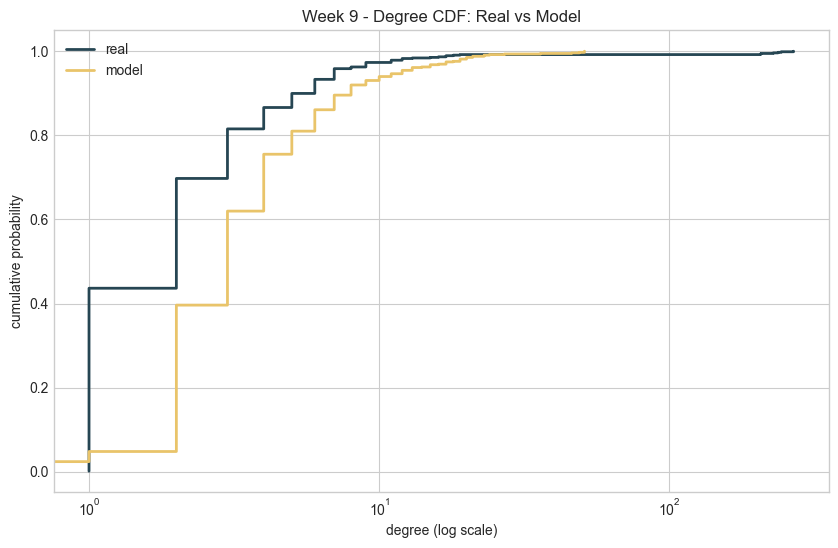

In [52]:
x_real, y_real = empirical_cdf([d for _, d in G_week9_real.degree()])
x_model, y_model = empirical_cdf([d for _, d in G_week9_model.degree()])

plt.figure(figsize=(10, 6))
plt.step(x_real, y_real, where="post", linewidth=2, color="#264653", label="real")
plt.step(x_model, y_model, where="post", linewidth=2, color="#e9c46a", label="model")
plt.xscale("log")
plt.xlabel("degree (log scale)")
plt.ylabel("cumulative probability")
plt.title("Week 9 - Degree CDF: Real vs Model")
plt.legend()
plt.show()


### **Graph Analysis**

The CDF comparison checks distributional fit beyond mean degree. Similarity in the lower and middle degree ranges would indicate that the model captures ordinary supporting characters reasonably well, while deviations in the tail reveal whether it reproduces the dominance of the main cast. In our case the curves agree closely on the bulk of low-degree nodes and diverge in the high-degree tail: the model produces a slightly heavier middle and a less extreme top, consistent with the lower model average clustering observed in section 9.2.

## **Week 10**


### **10.1 Model Background and Scenario Design**

We pick the **Independent Cascade Model (ICM)**. The choice is driven by what an "edge" represents in this graph: a co-appearance in the same Friends episode is a *one-shot* event - either it sparks a follow-up interaction or it doesn't, with no notion of repeated exposure or recovery. ICM is the model whose mechanics match this exactly: each newly infected node gets one chance to infect each susceptible neighbor with probability `p`, and once a node is infected it stays infected forever. SIS would let us oscillate in and out of infection, which has no interpretation here; threshold models would require us to invent fractional or absolute exposure thresholds that the data does not justify.

We test the three dimensions required by the task:

- outbreak size: 1, 3, or 5 seed nodes
- origin type: hub, peripheral, or random
- cascade probability: 0.05, 0.10, or 0.20 (for the headline scenario grid; section 10.4 sweeps a denser grid for hub starts)

The hub and peripheral seed policies are based on degree ranking, which directly connects this section to the centrality results from Week 5.

In [53]:
G_week10 = largest_component_graph(nx.Graph(G_unweighted))
G_week10.remove_edges_from(nx.selfloop_edges(G_week10))

degree_rank = pd.Series(dict(G_week10.degree())).sort_values(ascending=False)

def pick_seeds(origin_type: str, k: int, seed: int = 7):
    rng = random.Random(seed)
    if origin_type == "hub":
        return degree_rank.head(k).index.tolist()
    if origin_type == "peripheral":
        return degree_rank.sort_values().head(k).index.tolist()
    if origin_type == "random":
        return rng.sample(list(G_week10.nodes()), k)
    raise ValueError("origin_type must be hub, peripheral, or random")

seed_sizes = [1, 3, 5]
origins = ["hub", "peripheral", "random"]
p_values = [0.05, 0.10, 0.20]
trials = 20


### **Interpretation**

The setup creates a controlled grid of scenarios. Hub seeds represent the main-cast/core strategy, peripheral seeds represent weak starting positions, and random seeds provide a neutral comparison.


### **10.2 Simulation Grid Results**

For every scenario, we run repeated Independent Cascade simulations and summarize final reach and number of active steps.

The book describes the Independent Cascade Model using an influence probability `p_ij`: an active node `i` has probability `p_ij` of convincing an inactive neighbor `j`. In our code, this is implemented with a single scenario parameter `p` for all active-neighbor attempts.


In [54]:
def simulate_ic(
    G: nx.Graph,
    seeds,
    p: float,
    max_steps: int = 30,
    rng_seed: int = 7,
) -> dict:
    """Independent Cascade Model (synchronous rounds)."""
    rng = random.Random(rng_seed)
    infected = set(seeds)
    frontier = set(seeds)

    infected_counts = [len(infected)]
    new_infections_by_step = [set(seeds)]

    for _ in range(max_steps):
        if not frontier:
            break

        next_frontier = set()
        for source in frontier:
            for target in G.neighbors(source):
                if target in infected:
                    continue
                if rng.random() < p:
                    next_frontier.add(target)

        next_frontier = next_frontier - infected
        if not next_frontier:
            break

        infected |= next_frontier
        frontier = next_frontier

        infected_counts.append(len(infected))
        new_infections_by_step.append(set(next_frontier))

    return {
        "seeds": set(seeds),
        "infected": infected,
        "infected_counts": infected_counts,
        "new_infections_by_step": new_infections_by_step,
        "steps_run": len(infected_counts) - 1,
    }

rows = []
trajectories = {}

for seed_size in seed_sizes:
    for origin in origins:
        for p in p_values:
            final_sizes = []
            step_counts = []
            curves = []

            for t in range(trials):
                seeds = pick_seeds(origin, seed_size, seed=RANDOM_SEED + t)
                result = simulate_ic(
                    G_week10,
                    seeds=seeds,
                    p=p,
                    max_steps=30,
                    rng_seed=1000 + t,
                )
                counts = result["infected_counts"]
                assert all(counts[i] <= counts[i + 1] for i in range(len(counts) - 1))
                assert result["steps_run"] <= 30

                final_sizes.append(len(result["infected"]))
                step_counts.append(result["steps_run"])
                curves.append(counts)

            trajectories[(seed_size, origin, p)] = curves
            rows.append(
                {
                    "seed_size": seed_size,
                    "origin": origin,
                    "p": p,
                    "avg_final_infected": float(np.mean(final_sizes)),
                    "avg_final_share": float(np.mean(final_sizes) / G_week10.number_of_nodes()),
                    "avg_steps": float(np.mean(step_counts)),
                }
            )

week10_summary = pd.DataFrame(rows).sort_values(["seed_size", "origin", "p"])
display(week10_summary)


,seed_size,origin,p,avg_final_infected,avg_final_share,avg_steps
0,1,hub,0.05,42.00,0.056225,4.30
1,1,hub,0.10,139.65,0.186948,5.45
2,1,hub,0.20,255.55,0.342102,4.60
3,1,peripheral,0.05,1.60,0.002142,0.15
4,1,peripheral,0.10,7.45,0.009973,0.35
...,...,...,...,...,...,...
22,5,peripheral,0.10,73.70,0.098661,3.35
23,5,peripheral,0.20,156.50,0.209505,3.35
24,5,random,0.05,20.90,0.027979,2.00
25,5,random,0.10,101.45,0.135810,4.60


### **Interpretation**

The summary table shows the expected pattern: higher cascade probability and larger seed sets increase final reach. Origin also matters strongly. Hub starts consistently spread farther than peripheral starts, confirming the centrality results from Week 5 in a dynamic setting.


### **10.3 Effect of Origin and Outbreak Size**

At fixed probability `p = 0.10`, we compare the average final infected share by origin type (`hub`, `peripheral`, `random`) and seed size (1, 3, 5). This isolates the structural-position effect of where a cascade starts from the parametric effect of how strongly it propagates per edge.

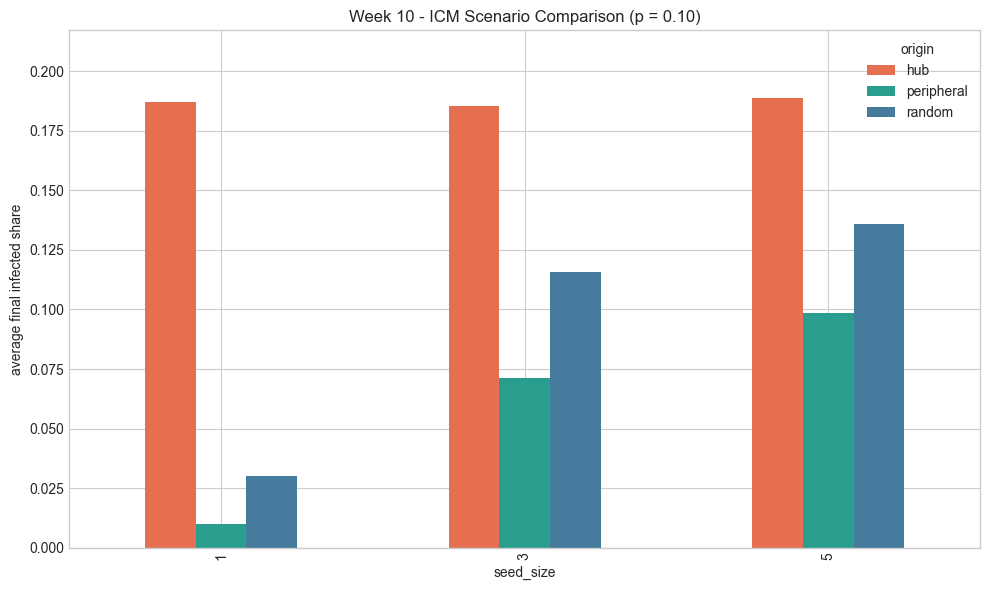

In [55]:
subset = week10_summary[week10_summary["p"] == 0.10]
pivot_plot = subset.pivot(index="seed_size", columns="origin", values="avg_final_share")
ax = pivot_plot.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#e76f51", "#2a9d8f", "#457b9d"],
)
ax.set_ylabel("average final infected share")
ax.set_title("Week 10 - ICM Scenario Comparison (p = 0.10)")
ax.set_ylim(0, pivot_plot.values.max() * 1.15)
ax.legend(title="origin")
plt.tight_layout()
plt.show()


### **Graph Analysis**

At the same transmission probability, hub-origin cascades outperform random and peripheral cascades across all seed sizes. The gap is especially visible for small outbreaks: a single hub seed reaches roughly **19%** of the network on average, while a single peripheral seed reaches only about **1%**, with random starts falling in between. This confirms that high-betweenness positions dominate dynamics in addition to dominating static centrality scores, because starting in the core gives the cascade immediate access to many parts of the network.

### **10.4 Effect of Cascade Probability**

We isolate hub-origin cascades and vary `p` to show how the transmission parameter changes final reach. Holding the structural-advantage origin fixed lets us read the curve as a sensitivity analysis of cascade probability alone, comparable across the three seed sizes.

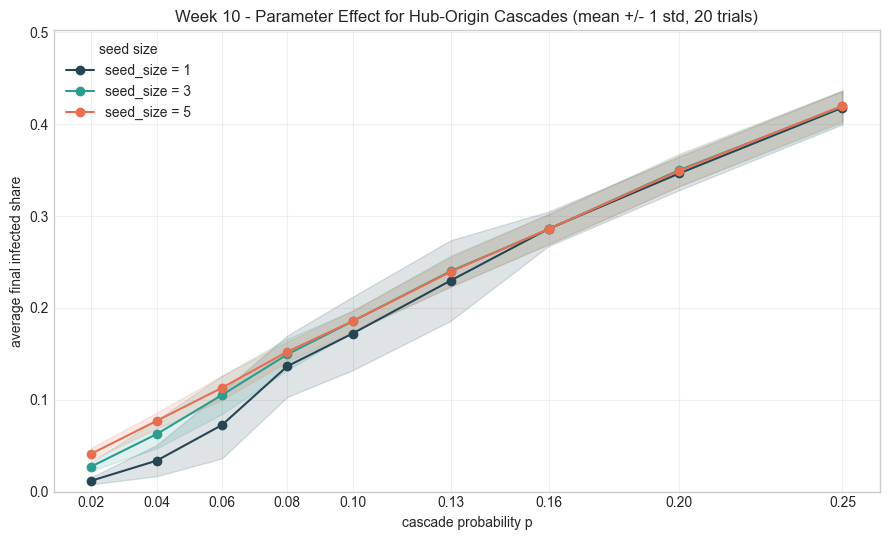

seed_size,1,3,5
p,,,
0.02,0.012,0.027,0.041
0.04,0.034,0.063,0.077
0.06,0.072,0.105,0.113
0.08,0.136,0.149,0.152
0.10,0.172,0.185,0.186
0.13,0.230,0.240,0.239
0.16,0.286,0.286,0.286
0.20,0.346,0.350,0.349
0.25,0.418,0.419,0.420


In [56]:
p_grid = [0.02, 0.04, 0.06, 0.08, 0.10, 0.13, 0.16, 0.20, 0.25]
hub_seed_sizes = [1, 3, 5]
hub_trials = trials  # reuse the global value (20)

n_total = G_week10.number_of_nodes()
records = []
for k in hub_seed_sizes:
    for p in p_grid:
        shares = []
        for t in range(hub_trials):
            seeds = pick_seeds("hub", k, seed=RANDOM_SEED + t)
            res = simulate_ic(
                G_week10, seeds=seeds, p=p, max_steps=30, rng_seed=2000 + t
            )
            shares.append(len(res["infected"]) / n_total)
        records.append(
            {
                "seed_size": k,
                "p": p,
                "mean_share": float(np.mean(shares)),
                "std_share": float(np.std(shares)),
            }
        )
hub_param_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {1: "#264653", 3: "#2a9d8f", 5: "#e76f51"}
for k in hub_seed_sizes:
    sub = hub_param_df[hub_param_df["seed_size"] == k].sort_values("p")
    m, s = sub["mean_share"].values, sub["std_share"].values
    ax.plot(sub["p"], m, marker="o", color=colors[k], label=f"seed_size = {k}")
    ax.fill_between(sub["p"], m - s, m + s, color=colors[k], alpha=0.15)

ax.set_xlabel("cascade probability p")
ax.set_ylabel("average final infected share")
ax.set_title(
    "Week 10 - Parameter Effect for Hub-Origin Cascades (mean +/- 1 std, 20 trials)"
)
ymax = (hub_param_df["mean_share"] + hub_param_df["std_share"]).max()
ax.set_ylim(0, min(1.0, ymax * 1.15))
ax.set_xticks(p_grid)
ax.grid(alpha=0.3)
ax.legend(title="seed size")
plt.tight_layout()
plt.show()

display(hub_param_df.pivot(index="p", columns="seed_size", values="mean_share").round(3))

### **Graph Analysis**

Increasing `p` raises the final infected share for every hub-seeded outbreak size. Larger seed sets help, but the probability parameter remains decisive because each active edge has a greater chance of carrying the cascade forward. The curves climb roughly monotonically with `p` and start to flatten as the cascade saturates the giant component. The seed-size advantage also shrinks at high `p`: once each edge fires reliably, three or five hub seeds reach roughly the same plateau as one well-placed seed, suggesting that in this graph cascade probability dominates seed budget.

## **Conclusion**

- **Our main findings:** The Friends interaction graph has **747 nodes**, **1610 edges**, average degree **4.31**, and density **0.0058** - sparse globally, tightly bound around the six main characters. Average clustering is **0.50** while transitivity is just **0.034**, the canonical signature of a hub-and-spoke graph: small groups around the cast are highly closed, but the cast itself bridges so many disjoint groups that triangles are rare overall. Greedy modularity on the LCC finds **11 communities** at modularity **0.404**. Top-degree seeds reach about **19 %** of the graph at `p = 0.10` under the Independent Cascade Model, while peripheral seeds barely escape their starting clique (around **1 %**) - a dynamic restatement of the Week 5 centrality ranking.

- **What our analyses tell us:** Week 1 establishes scale and sparsity. Week 2 and Week 3 show the split between high local clustering in small groups and low global transitivity around the cast core. Week 5 confirms that the same handful of characters dominate both betweenness and PageRank. Week 6 finds meaningful community structure with greedy modularity giving the strongest partition. Week 7 ranks missing-link candidates that all sit inside shared story circles. Weeks 9-10 then take the structural picture and stress-test it: the custom preferential-attachment-plus-triadic-closure model recovers scale and average degree exactly but undershoots clustering by roughly 25 %, and the cascade simulation shows that hub starts and cascade probability are the two levers that actually matter for diffusion reach.

- **Caveats:** The graph is aggregated and undirected, so it does not preserve the order, duration, or direction of interactions. Edge weights count repeated pair appearances, but most structural tasks intentionally use the unweighted graph to match the assignment requirements. The custom random graph model is calibrated for scale and average degree, yet it cannot fully reproduce the narrative mechanisms that create Friends-specific clustering. Finally, the contagion model is a simplified abstraction of influence rather than a causal model of real behavior.